In [1]:
# to suppress pink warning boxes
import warnings
warnings.filterwarnings(action="ignore")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression   
import pandas as pd
from scipy import optimize
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

#### We have some data on how many hours some students have studied and their results (pass/fail). Lets make a model that will predict a student's result based on the number of hours studied

Text(0, 0.5, 'pass(1) or fail(0)')

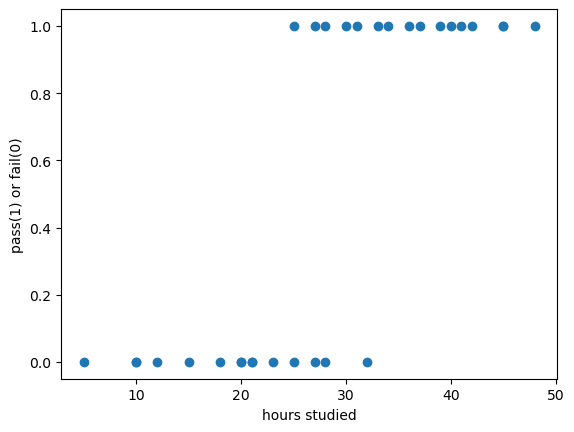

In [3]:
hours=[42,40,45,23,34,41,39,36,28,20,37,10,30,31,20,12,18,21,15,27,25,21,32,45,27,10,33,28,25,48,5]
result=[1,1,1,0,1,1,1,1,0,0,1,0,1,1,0,0,0,0,0,1,1,0,0,1,0,0,1,1,0,1,0]
plt.scatter(hours,result)
plt.xlabel("hours studied")
plt.ylabel("pass(1) or fail(0)")

In [4]:
dic={"Hours":hours,"Result":result}

In [5]:
data=pd.DataFrame(dic)
data

,Hours,Result
0,42,1
1,40,1
2,45,1
3,23,0
4,34,1
5,41,1
6,39,1
7,36,1
8,28,0
9,20,0


In [6]:
def logfunc(x,a,b):
    return 1/(1+np.exp(-(a*x+b)))

p,p_cov=optimize.curve_fit(logfunc,data["Hours"],data["Result"])

In [7]:
p

array([ 0.35230688, -9.59433001])

In [8]:
pred=1/(1+np.exp(-(p[0]*data["Hours"]+p[1])))
data["predicted probability of passing"]=pred
pf=[]

for i in range(len(data)):
    if data["predicted probability of passing"][i]>=0.5:
        pf.append(1)
    else:
        pf.append(0)
        
data["pass/fail prediction"]=pf
data

,Hours,Result,predicted probability of passing,pass/fail prediction
0,42,1,0.994528,1
1,40,1,0.988991,1
2,45,1,0.998091,1
3,23,0,0.183731,0
4,34,1,0.915607,1
5,41,1,0.992234,1
6,39,1,0.984413,1
7,36,1,0.956425,1
8,28,0,0.567157,1
9,20,0,0.072548,0


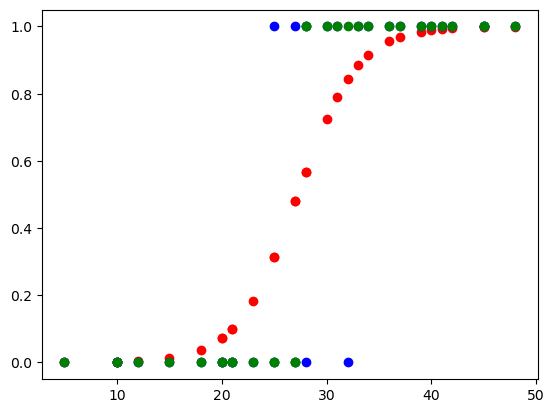

In [9]:
plt.scatter(data["Hours"],pred,color="r")
plt.scatter(data["Hours"],data["Result"],color="b")
plt.scatter(data["Hours"],data["pass/fail prediction"],color="g")

## model building using sklearn

In [10]:
x=data[["Hours"]]
y=data["Result"]

In [11]:
log_reg=LogisticRegression()

In [12]:
log_reg.fit(x,y)

LogisticRegression()

In [13]:
b=log_reg.intercept_

In [14]:
b

array([-11.22651531])

In [15]:
a=log_reg.coef_

In [16]:
a

array([[0.40693725]])

In [17]:
y_0_1=log_reg.predict(data[["Hours"]])

In [18]:
y_0_1  ## predicts result as 0 or 1

array([1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 1, 1, 0, 1, 0], dtype=int64)

In [19]:
y_pred=log_reg.predict_proba(data[["Hours"]])
y_pred## predicts probability of "passing"
# col 0: probability of 0(fail)
# col 1: probability of 1(pass)

array([[2.82942265e-03, 9.97170577e-01],
       [6.36235083e-03, 9.93637649e-01],
       [8.36321388e-04, 9.99163679e-01],
       [8.66105967e-01, 1.33894033e-01],
       [6.85390144e-02, 9.31460986e-01],
       [4.24435547e-03, 9.95755645e-01],
       [9.52714455e-03, 9.90472855e-01],
       [3.15774373e-02, 9.68422563e-01],
       [4.58166110e-01, 5.41833890e-01],
       [9.56385455e-01, 4.36145454e-02],
       [2.12449348e-02, 9.78755065e-01],
       [9.99221329e-01, 7.78671116e-04],
       [2.72573993e-01, 7.27426007e-01],
       [1.99641032e-01, 8.00358968e-01],
       [9.56385455e-01, 4.36145454e-02],
       [9.98244542e-01, 1.75545830e-03],
       [9.80191655e-01, 1.98083447e-02],
       [9.35886129e-01, 6.41138712e-02],
       [9.94073967e-01, 5.92603319e-03],
       [5.59518853e-01, 4.40481147e-01],
       [7.41366686e-01, 2.58633314e-01],
       [9.35886129e-01, 6.41138712e-02],
       [1.42402579e-01, 8.57597421e-01],
       [8.36321388e-04, 9.99163679e-01],
       [5.595188

In [20]:
data["sklearn prediction"]=y_0_1
data["sklearn probability prediction"]=y_pred[:,1]

In [21]:
data

,Hours,Result,predicted probability of passing,pass/fail prediction,sklearn prediction,sklearn probability prediction
0,42,1,0.994528,1,1,0.997171
1,40,1,0.988991,1,1,0.993638
2,45,1,0.998091,1,1,0.999164
3,23,0,0.183731,0,0,0.133894
4,34,1,0.915607,1,1,0.931461
5,41,1,0.992234,1,1,0.995756
6,39,1,0.984413,1,1,0.990473
7,36,1,0.956425,1,1,0.968423
8,28,0,0.567157,1,1,0.541834
9,20,0,0.072548,0,0,0.043615


## Accuracy of the model

https://developers.google.com/machine-learning/crash-course/classification/accuracy

In [25]:
#using basic python
def accuracy(a,b):
    correct=0
    for i in range(len(a)):
        if a[i]==b[i]:
            correct+=1
    return correct/len(a)

In [26]:
acc=accuracy(data["Result"],data["pass/fail prediction"])
acc

0.8709677419354839

In [27]:
# using sklearn.metrics accuracy_score()

acc_sk=accuracy_score(data["Result"],data["pass/fail prediction"])
acc_sk

0.8709677419354839